In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    average_precision_score
)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Save models
import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
fraud_df = pd.read_csv("../data/processed/fraud_feature_engineered.csv")

credit_df = pd.read_csv("../data/processed/creditcard_clean.csv")

In [3]:
X_fraud = fraud_df.drop("class", axis=1)

y_fraud = fraud_df["class"]

In [4]:
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

In [5]:
X_train_fraud.select_dtypes(include=['object']).columns.tolist()

['device_id']

In [6]:
fraud_df = fraud_df.drop(
    columns=[
        'device_id'
    ]
)

In [7]:
fraud_df.select_dtypes(exclude=['number']).columns.tolist()

['source_Direct',
 'source_SEO',
 'browser_FireFox',
 'browser_IE',
 'browser_Opera',
 'browser_Safari',
 'sex_M',
 'country_Albania',
 'country_Algeria',
 'country_Angola',
 'country_Antigua and Barbuda',
 'country_Argentina',
 'country_Armenia',
 'country_Australia',
 'country_Austria',
 'country_Azerbaijan',
 'country_Bahamas',
 'country_Bahrain',
 'country_Bangladesh',
 'country_Barbados',
 'country_Belarus',
 'country_Belgium',
 'country_Belize',
 'country_Benin',
 'country_Bermuda',
 'country_Bhutan',
 'country_Bolivia',
 'country_Bonaire; Sint Eustatius; Saba',
 'country_Bosnia and Herzegowina',
 'country_Botswana',
 'country_Brazil',
 'country_British Indian Ocean Territory',
 'country_Brunei Darussalam',
 'country_Bulgaria',
 'country_Burkina Faso',
 'country_Burundi',
 'country_Cambodia',
 'country_Cameroon',
 'country_Canada',
 'country_Cape Verde',
 'country_Cayman Islands',
 'country_Chile',
 'country_China',
 'country_Colombia',
 'country_Congo',
 'country_Congo The Democ

In [8]:
X_train_fraud.select_dtypes(include=['object']).columns.tolist()

['device_id']

In [9]:
fraud_df.dtypes.value_counts()

bool       187
int64        9
float64      3
Name: count, dtype: int64

In [10]:
bool_cols = fraud_df.select_dtypes(include=['bool']).columns

fraud_df[bool_cols] = fraud_df[bool_cols].astype(int)

In [11]:
fraud_df.select_dtypes(exclude=['number']).columns.tolist()

[]

In [12]:
X_fraud = fraud_df.drop('class', axis=1)
y_fraud = fraud_df['class']

In [13]:
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

Applying SMOTE

In [14]:
smote = SMOTE(random_state=42)

X_train_fraud_smote, y_train_fraud_smote = smote.fit_resample(
    X_train_fraud,
    y_train_fraud
)

In [15]:
print(y_train_fraud.value_counts())

class
0    93502
1     9814
Name: count, dtype: int64


In [16]:
print(y_train_fraud_smote.value_counts())

class
0    93502
1    93502
Name: count, dtype: int64


Logistic Regression Baseline

In [17]:
lr_fraud = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_fraud.fit(
    X_train_fraud_smote,
    y_train_fraud_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
fraud_pred_lr = lr_fraud.predict(X_test_fraud)

fraud_prob_lr = lr_fraud.predict_proba(
    X_test_fraud
)[:,1]

In [19]:
f1_lr_fraud = f1_score(
    y_test_fraud,
    fraud_pred_lr
)

print(f1_lr_fraud)

0.28902428559169313


In [20]:
aucpr_lr_fraud = average_precision_score(
    y_test_fraud,
    fraud_prob_lr
)

print(aucpr_lr_fraud)

0.3236964536464007


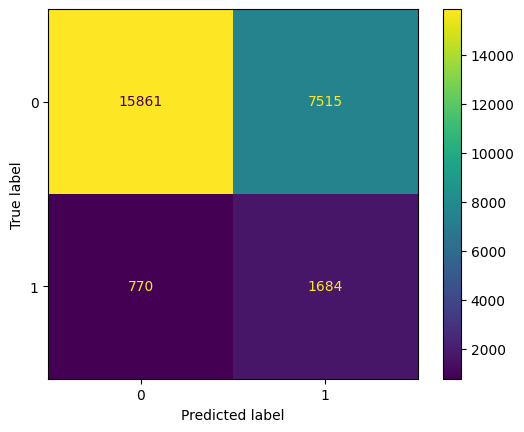

In [21]:
cm = confusion_matrix(
    y_test_fraud,
    fraud_pred_lr
)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [24]:
fraud_pred_lr = lr_fraud.predict(X_test_fraud)

fraud_prob_lr = lr_fraud.predict_proba(
    X_test_fraud
)[:,1]

Random Forest

In [25]:
rf_fraud = RandomForestClassifier(
    random_state=42
)

In [26]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

In [27]:
grid_rf = GridSearchCV(
    rf_fraud,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(
    X_train_fraud_smote,
    y_train_fraud_smote
)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [29]:
hasattr(grid_rf, "best_estimator_")

True

In [30]:
best_rf_fraud = grid_rf.best_estimator_

print(grid_rf.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [31]:
rf_pred = best_rf_fraud.predict(
    X_test_fraud
)

rf_prob = best_rf_fraud.predict_proba(
    X_test_fraud
)[:,1]

In [33]:
y_pred_lr = lr_fraud.predict(X_test_fraud)

y_prob_lr = lr_fraud.predict_proba(X_test_fraud)[:, 1]

In [36]:
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

y_pred_lr = lr_fraud.predict(X_test_fraud)
y_prob_lr = lr_fraud.predict_proba(X_test_fraud)[:,1]

print("F1 Score:")
print(f1_score(y_test_fraud, y_pred_lr))

print("\nAUC-PR:")
print(average_precision_score(y_test_fraud, y_prob_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_fraud, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test_fraud, y_pred_lr))

F1 Score:
0.28902428559169313

AUC-PR:
0.3236964536464007

Confusion Matrix:
[[15861  7515]
 [  770  1684]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79     23376
           1       0.18      0.69      0.29      2454

    accuracy                           0.68     25830
   macro avg       0.57      0.68      0.54     25830
weighted avg       0.88      0.68      0.75     25830



In [41]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [42]:
cv_lr = cross_val_score(
    lr_fraud,
    X_fraud,
    y_fraud,
    cv=skf,
    scoring="f1"
)

print(cv_lr.mean())
print(cv_lr.std())

0.0
0.0


CREDIT CARD MODELING

In [48]:
credit_df = pd.read_csv(
    "../data/processed/creditcard_clean.csv"
)

In [49]:
X_credit = credit_df.drop(
    "Class",
    axis=1
)

y_credit = credit_df["Class"]

In [50]:
from sklearn.model_selection import train_test_split

X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit,
    y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

In [51]:
print(y_train_credit.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_credit_smote, y_train_credit_smote = smote.fit_resample(
    X_train_credit,
    y_train_credit
)

In [53]:
print(
    y_train_credit_smote.value_counts()
)

Class
0    226602
1    226602
Name: count, dtype: int64


Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression

log_credit = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_credit.fit(
    X_train_credit_smote,
    y_train_credit_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [55]:
y_pred_log_credit = log_credit.predict(
    X_test_credit
)

y_prob_log_credit = log_credit.predict_proba(
    X_test_credit
)[:,1]

In [56]:
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    confusion_matrix
)

print(
    f1_score(
        y_test_credit,
        y_pred_log_credit
    )
)

print(
    average_precision_score(
        y_test_credit,
        y_prob_log_credit
    )
)

print(
    confusion_matrix(
        y_test_credit,
        y_pred_log_credit
    )
)

0.2231404958677686
0.7069604677652589
[[56101   550]
 [   14    81]]


In [ ]:
Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_credit = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf_credit.fit(
    X_train_credit_smote,
    y_train_credit_smote
)

KeyboardInterrupt: 

In [60]:
X_train_fraud.dtypes.value_counts()

int64      195
float64      3
Name: count, dtype: int64

In [61]:
y_pred_rf_credit = rf_credit.predict(
    X_test_credit
)

y_prob_rf_credit = rf_credit.predict_proba(
    X_test_credit
)[:,1]

IndexError: list index out of range

In [ ]:
print(
    f1_score(
        y_test_credit,
        y_pred_rf_credit
    )
)

print(
    average_precision_score(
        y_test_credit,
        y_prob_rf_credit
    )
)

print(
    confusion_matrix(
        y_test_credit,
        y_pred_rf_credit
    )
)

In [ ]:
comparison_credit = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "F1 Score":[
        f1_score(
            y_test_credit,
            y_pred_log_credit
        ),
        f1_score(
            y_test_credit,
            y_pred_rf_credit
        )
    ],
    "AUC-PR":[
        average_precision_score(
            y_test_credit,
            y_prob_log_credit
        ),
        average_precision_score(
            y_test_credit,
            y_prob_rf_credit
        )
    ]
})

comparison_credit